## Importy 

In [120]:
import pandas as pd 
from features import extract_features
from modelsUnet import UNet4Levels, UNet, predict_masks, preprocess_image, test_model
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataset import train_loader, val_loader, test_loader
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

# TRAIN I TEST SET

In [121]:
df1 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train_new_unet.csv')
df2 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val_new_unet.csv')
df_test = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test_new_unet.csv')
df_train = pd.concat([df1, df2], ignore_index=True)


In [122]:
df1.shape, df2.shape, df_test.shape

((461, 26), (97, 26), (103, 26))

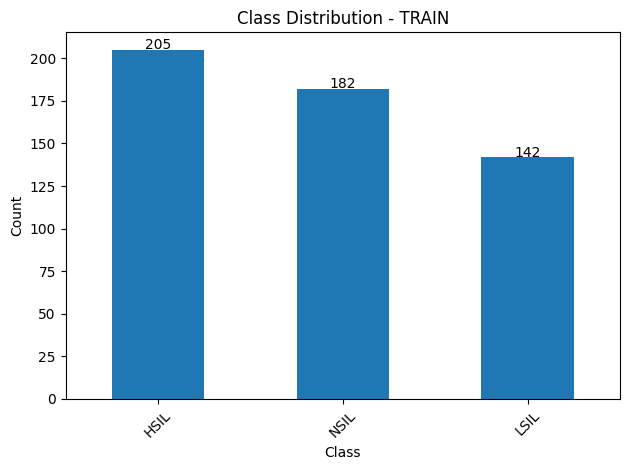

In [123]:
df_train = df_train[df_train['N'] != 0]
df_train['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TRAIN')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_train['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

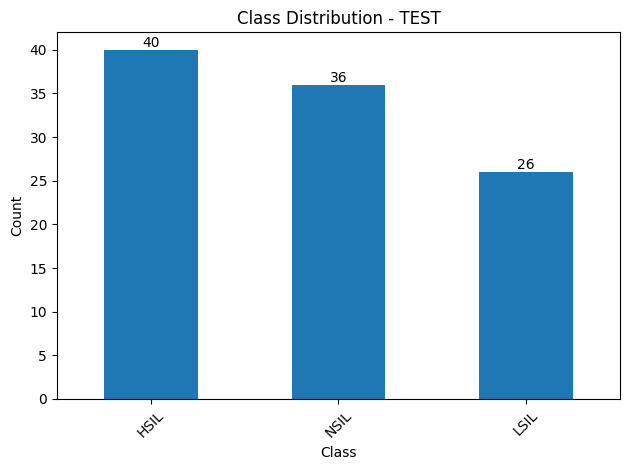

In [124]:
df_test = df_test[df_test['N'] != 0]
df_test['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TEST')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_test['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [125]:
df_train.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr,class
0,6351,17492,0.363080,410.391916,1065.997036,0.384984,61.330521,0.600752,145.526630,0.521758,...,0.947769,0.795706,1.191105,89.924103,149.236410,0.602561,-0.239361,0.040196,-5.954837,HSIL
1,5550,12251,0.453024,348.232536,492.114785,0.707625,59.385822,0.715382,121.918005,0.589975,...,0.954428,0.997720,0.956610,84.062355,124.893786,0.673071,14.904083,35.629260,0.418310,HSIL
2,978,3125,0.312960,162.568541,287.338093,0.565774,17.233763,0.521670,68.658576,0.553968,...,0.956947,0.996492,0.960316,35.287792,63.078313,0.559428,-0.439244,-0.458938,0.957087,HSIL
3,864,2465,0.350507,152.752307,236.007140,0.647236,16.963255,0.517228,65.192024,0.663122,...,0.945295,0.998380,0.946829,33.167438,56.022634,0.592036,-2.856079,-7.153759,0.399242,HSIL
4,13099,44180,0.296492,697.511754,960.950353,0.725856,108.330750,0.582786,197.294197,0.570527,...,0.869672,0.992597,0.876158,129.143969,237.174457,0.544510,-2.943298,4.890625,-0.601824,HSIL


In [126]:
df_train.shape

(529, 26)

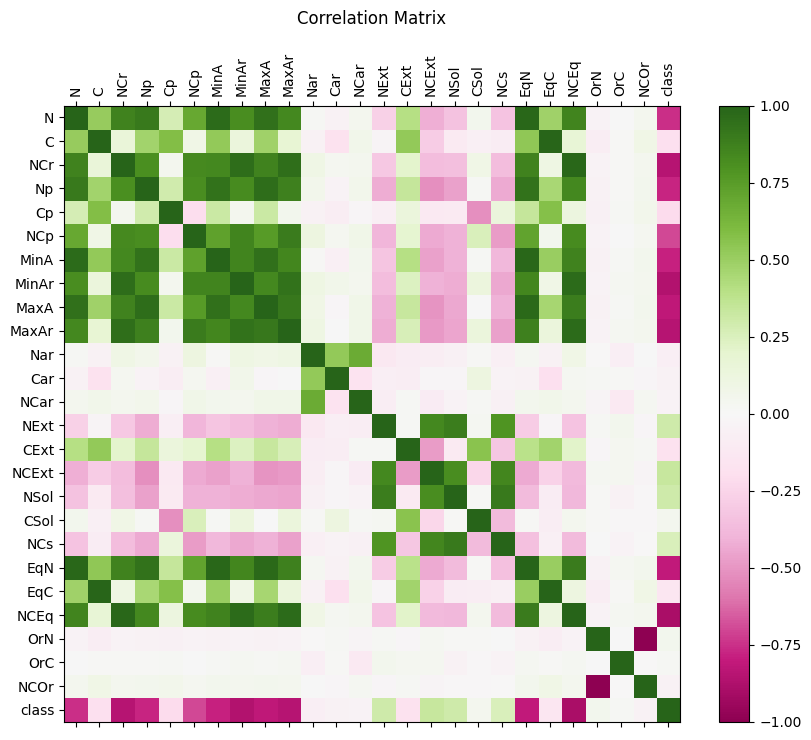

In [127]:
mapa = {"HSIL": 0, "LSIL": 1, "NSIL": 2}
df_corr = df_train.copy()
df_corr["class"] = df_corr["class"].map(mapa)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="PiYG")  
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

In [128]:
X_train, y_train = df_train.drop(columns=["class"]), df_train["class"]
X_test,  y_test  = df_test.drop(columns=["class"]),  df_test["class"]

## Uczenie z KFold i GridSearch (scalar i smote w pipeline - aby nie było wycieku danych)

In [129]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(probability=True, random_state=42))
])

pipe_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", MLPClassifier(solver="adam", random_state=42))
])

pipe_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipelines = {
    "SVM": pipe_svm,
    "NeuralNet": pipe_mlp,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
}

param_grids = {
    "SVM": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "clf__kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "clf__hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "clf__activation": ["relu", "tanh", "logistic"],
        "clf__batch_size": [32, 64, 16],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 1e-2], 
        "clf__n_iter_no_change": [10, 20],
        "clf__max_iter": [300, 600, 1000],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 500],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
    },

}

In [130]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train) 

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [131]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"models_paths/best_model_{name}_311.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:05:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Results ===
          Model Split                                        Best_Params  \
2  RandomForest  Test  {'clf__max_depth': 10, 'clf__min_samples_leaf'...   
3       XGBoost  Test  {'clf__colsample_bytree': 0.8, 'clf__learning_...   
0           SVM  Test  {'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...   
1     NeuralNet  Test  {'clf__activation': 'tanh', 'clf__alpha': 0.00...   

   Accuracy  Precision    Recall        F1  
2  0.911765   0.903371  0.906125  0.904601  
3  0.901961   0.892700  0.894231  0.893357  
0  0.872549   0.863379  0.861966  0.862566  
1  0.862745   0.848989  0.845584  0.846799  


In [132]:
results.to_excel("ml_311.xlsx", index=False)

In [133]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
2,RandomForest,Test,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.911765,0.903371,0.906125,0.904601
3,XGBoost,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.901961,0.892700,0.894231,0.893357
0,SVM,Test,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",0.872549,0.863379,0.861966,0.862566
1,NeuralNet,Test,"{'clf__activation': 'tanh', 'clf__alpha': 0.00...",0.862745,0.848989,0.845584,0.846799


In [134]:

def predict(pipe, label_encoder, input_features):
    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    try:
        X_new = pd.DataFrame([[input_features[feat] for feat in feature_names]], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class


In [135]:
classifier = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet_311.pkl")
label_encoder = classifier["label_encoder"]
pipe = classifier["model"]


In [136]:
features = {'N': np.uint64(4439), 'C': np.uint64(262118), 'NCr': np.float64(0.016935120823445927), 'Np': 277.49747383594513, 'Cp': 2309.796025156975, 'NCp': 0.12013938495590158, 'MinA': 73.0, 'MinAr': 0.12784588441331, 'MaxA': np.float64(83.35466393669883), 'MaxAr': np.float64(0.12441202480634707), 'Nar': 1.0405405405405406, 'Car': 1.0367132867132867, 'NCar': 1.0036917187001504, 'NExt': np.float64(0.7790452790452791), 'CExt': np.float64(0.772762650502954), 'NCExt': np.float64(1.008130088246677), 'NSol': np.float64(0.9855683836589698), 'CSol': np.float64(0.9516233848745476), 'NCs': np.float64(1.0356706227736272), 'EqN': np.float64(75.17918820444517), 'EqC': np.float64(577.7014825901795), 'NCEq': np.float64(0.13013500998365476), 'OrN': np.float64(1.446102061602086), 'OrC': np.float64(4.140502931377116), 'NCOr': np.float64(0.349257586715708)}
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Predicted class: NSIL


In [137]:
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def plot_multiclass_roc(model, label_encoder, classes, X_test, y_test, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)  
    y_true_enc = label_encoder.transform(y_test)               
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))

    macro_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")
    hex_colors = [
        "#96e796", "#24c715", "#117a22"
       
    ]
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)
        color = hex_colors[i % len(hex_colors)]
        plt.plot(fpr, tpr, color=color, label=f"{cls} (AUC = {cls_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Greens, colorbar=False)
    plt.title(title)
    plt.show()


def print_classification_metrics(y_true, y_pred, classes, title="Classification Metrics"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    rec_macro = recall_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, labels=classes, average="macro", zero_division=0)
    print(f"\n=== {title} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec_macro:.4f}")
    print(f"Recall (macro):    {rec_macro:.4f}")
    print(f"F1 (macro):        {f1_macro:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=classes, digits=4))


## NN

In [138]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet_311.pkl")

In [139]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

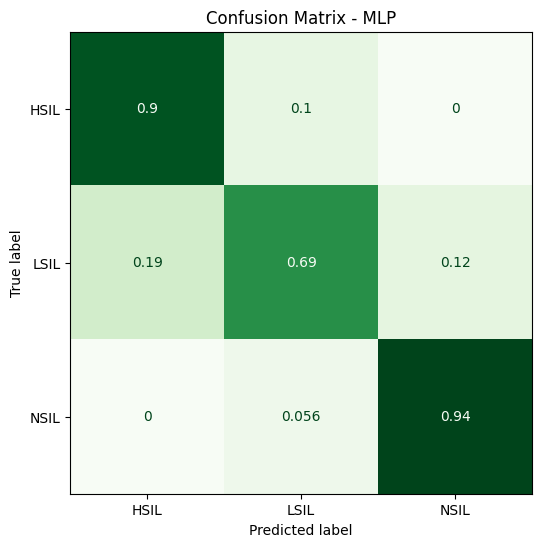

In [140]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - MLP")

In [141]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.8627
Precision (macro): 0.8490
Recall (macro):    0.8456
F1 (macro):        0.8468

Classification report:
              precision    recall  f1-score   support

        HSIL     0.8780    0.9000    0.8889        40
        LSIL     0.7500    0.6923    0.7200        26
        NSIL     0.9189    0.9444    0.9315        36

    accuracy                         0.8627       102
   macro avg     0.8490    0.8456    0.8468       102
weighted avg     0.8598    0.8627    0.8609       102



Macro AUC (OvR): 0.9406


<Figure size 800x600 with 0 Axes>

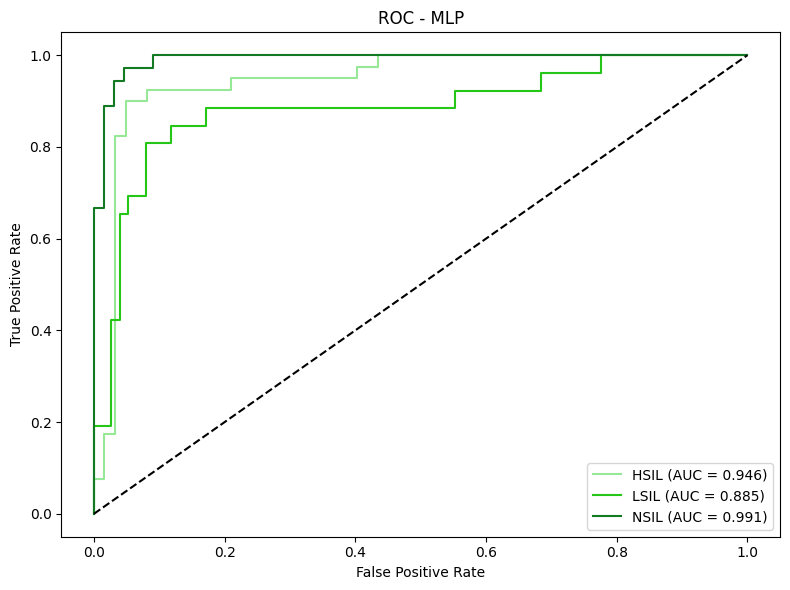

In [142]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title=f"ROC - MLP")


## XGBOOST

In [143]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_XGBoost_311.pkl")


In [144]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

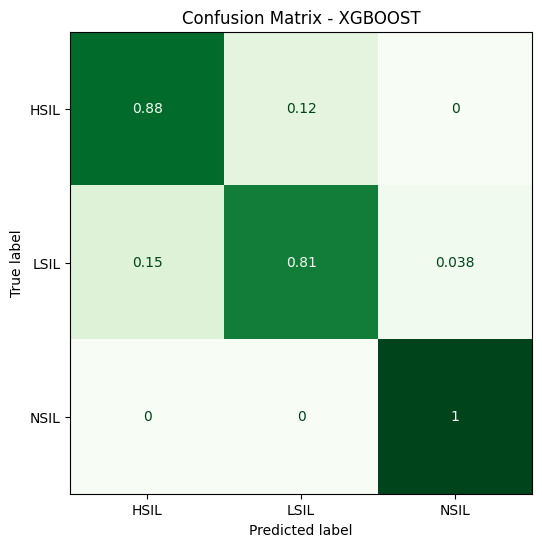

In [145]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - XGBOOST")

In [146]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.9020
Precision (macro): 0.8927
Recall (macro):    0.8942
F1 (macro):        0.8934

Classification report:
              precision    recall  f1-score   support

        HSIL     0.8974    0.8750    0.8861        40
        LSIL     0.8077    0.8077    0.8077        26
        NSIL     0.9730    1.0000    0.9863        36

    accuracy                         0.9020       102
   macro avg     0.8927    0.8942    0.8934       102
weighted avg     0.9012    0.9020    0.9015       102



Macro AUC (OvR): 0.9659


<Figure size 800x600 with 0 Axes>

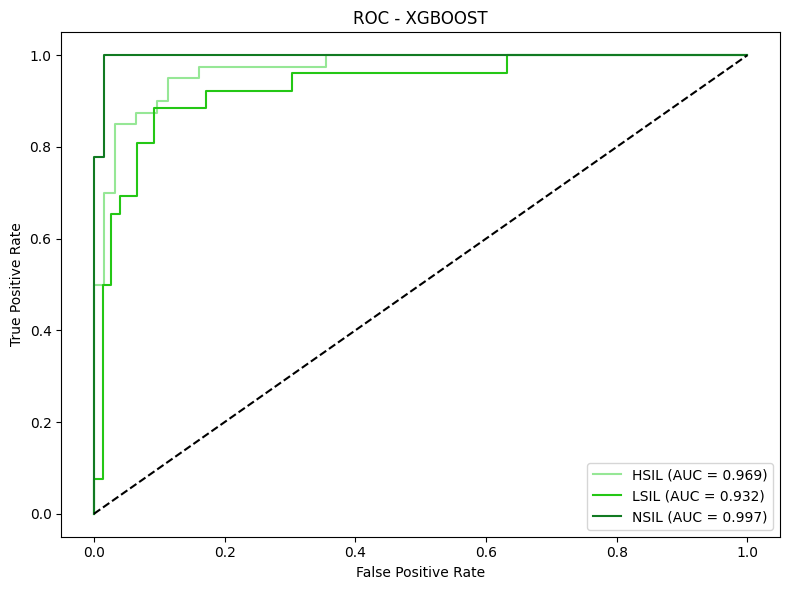

In [147]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC - XGBOOST")


## SVM

In [148]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_SVM_311.pkl")
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

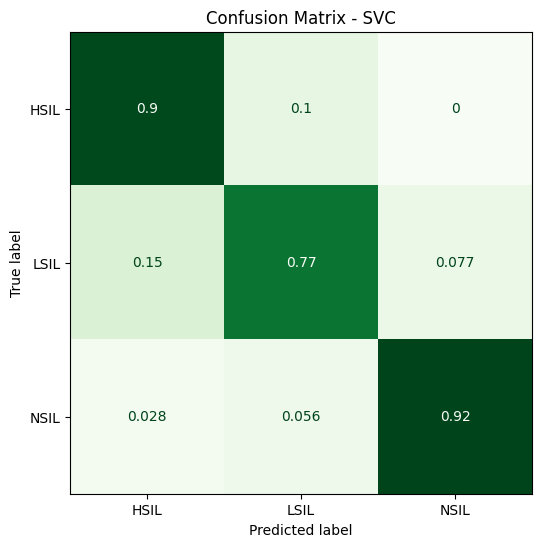

In [149]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - SVC")

In [150]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.8725
Precision (macro): 0.8634
Recall (macro):    0.8620
F1 (macro):        0.8626

Classification report:
              precision    recall  f1-score   support

        HSIL     0.8780    0.9000    0.8889        40
        LSIL     0.7692    0.7692    0.7692        26
        NSIL     0.9429    0.9167    0.9296        36

    accuracy                         0.8725       102
   macro avg     0.8634    0.8620    0.8626       102
weighted avg     0.8732    0.8725    0.8727       102



Macro AUC (OvR): 0.9654


<Figure size 800x600 with 0 Axes>

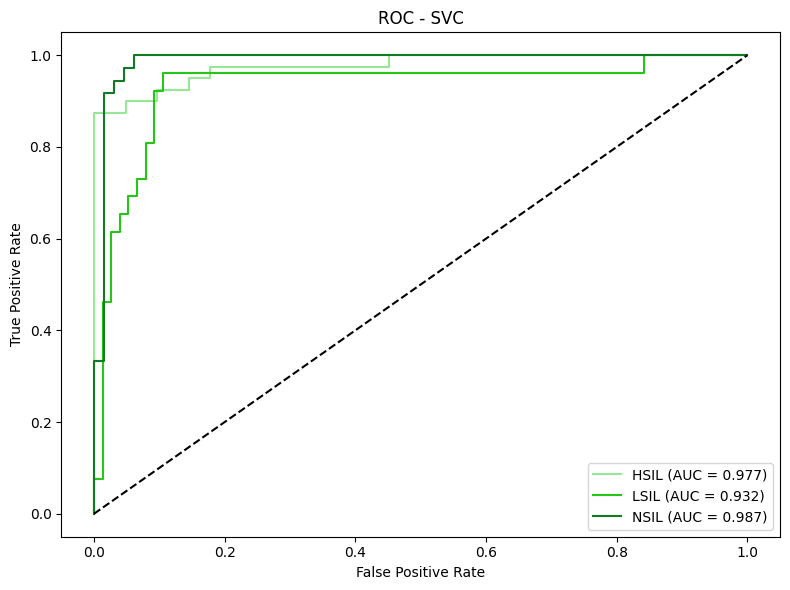

In [151]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC - SVC")

## RF

In [152]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_311.pkl")


In [153]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

In [154]:
print_classification_metrics(y_test, y_test_pred, classes)


=== Classification Metrics ===
Accuracy:  0.9118
Precision (macro): 0.9034
Recall (macro):    0.9061
F1 (macro):        0.9046

Classification report:
              precision    recall  f1-score   support

        HSIL     0.9231    0.9000    0.9114        40
        LSIL     0.8148    0.8462    0.8302        26
        NSIL     0.9722    0.9722    0.9722        36

    accuracy                         0.9118       102
   macro avg     0.9034    0.9061    0.9046       102
weighted avg     0.9128    0.9118    0.9122       102



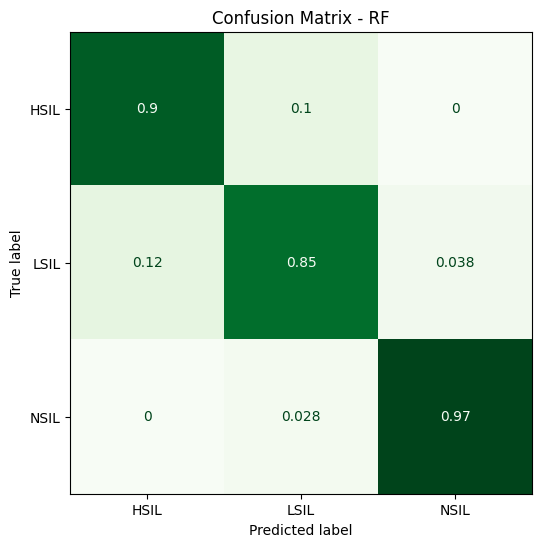

In [155]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - RF")

Macro AUC (OvR): 0.9627


<Figure size 800x600 with 0 Axes>

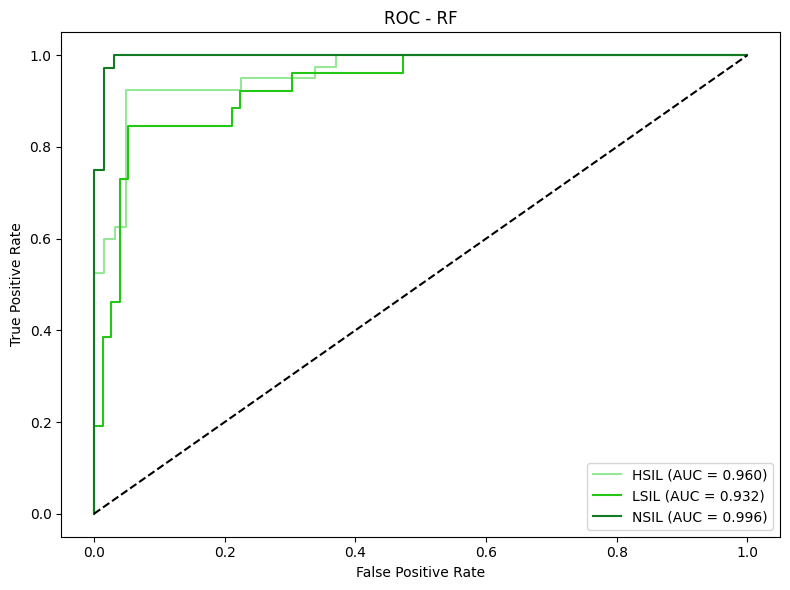

In [156]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC - RF")

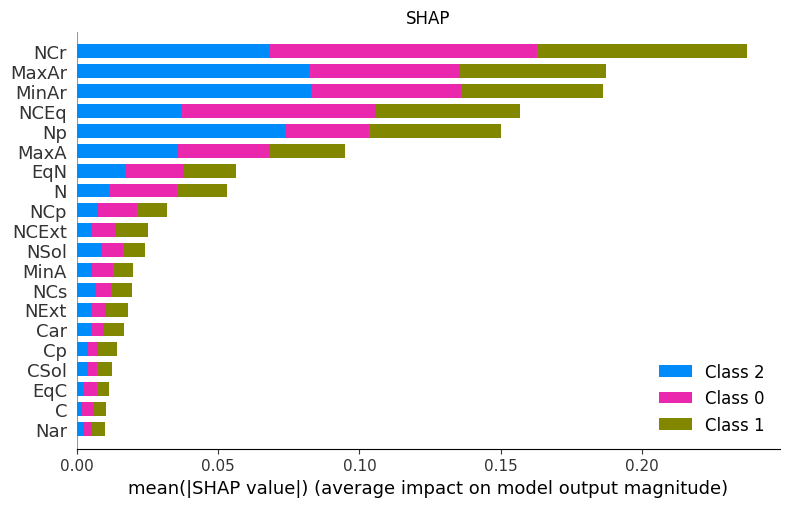

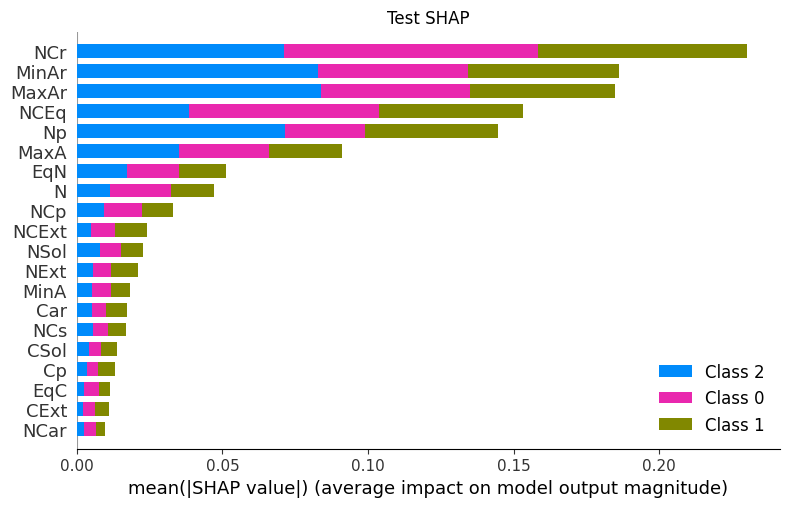

In [159]:
import shap

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_311.pkl")
train_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(df_train.drop('class', axis=1))
test_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(X_test)

plt.subplot(2, 1, 1)
plt.title('SHAP')
shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

plt.subplot(2, 1, 2)
plt.title('Test SHAP')
shap.summary_plot(test_shap_values, X_test, plot_type="bar")

## USUWANIE SKORELOWANYCH CECH

In [ ]:
def find_correlated_features_to_drop(X_train: pd.DataFrame, 
                                     y_train: pd.Series, 
                                     threshold: float = 0.9):
    corr_matrix = X_train.corr().abs()
    try:
        target_corr = X_train.corrwith(y_train).abs()
    except Exception as e:
        print(f"Błąd przy obliczaniu korelacji z y: {e}")
        print("Upewnij się, że y_train jest typu pandas.Series i ma ten sam indeks co X_train.")
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    features_to_drop = set()
        
    print(f"--- Rozpoczynam poszukiwanie cech do usunięcia (próg = {threshold}) ---")
        
    for i in range(len(upper.columns)):
        for j in range(i):
            if upper.iloc[j, i] > threshold:
                feature_i = upper.columns[i]
                feature_j = upper.columns[j]
                    
                if feature_i in features_to_drop or feature_j in features_to_drop:
                    continue
                        
                if (target_corr[feature_i] < target_corr[feature_j]) and (feature_i not in ['NCr', 'MaxAr', 'MinAr', 'NCEq', 'Np', 'MaxA', 'EqN', 'N', 'NCp', 'NCExt', 'NSol', 'NCs', 'MinA', 'Car', 'CSol']):
                    features_to_drop.add(feature_i)
                    print(f"Para: ({feature_i}, {feature_j}) > {threshold:.2f}. "
                            f"Korel. z y: {feature_i} ({target_corr[feature_i]:.3f}) < {feature_j} ({target_corr[feature_j]:.3f}). "
                            f"-> Usuwam: {feature_i}")
                elif (feature_i not in ['NCr', 'MaxAr', 'MinAr', 'NCEq', 'Np', 'MaxA', 'EqN', 'N', 'NCp', 'NCExt', 'NSol', 'NCs', 'MinA', 'Car', 'CSol']):
                    features_to_drop.add(feature_j) 
                    print(f"Para: ({feature_i}, {feature_j}) > {threshold:.2f}. "
                            f"Korel. z y: {feature_j} ({target_corr[feature_j]:.3f}) <= {feature_i} ({target_corr[feature_i]:.3f}). "
                            f"-> Usuwam: {feature_j}")
                            
    print(f"--- Zakończono. Znaleziono {len(features_to_drop)} cech do usunięcia ---")
    return list(features_to_drop)

In [ ]:
features_to_drop = find_correlated_features_to_drop(X_train, pd.Series(y_train_enc), 0.85)

--- Rozpoczynam poszukiwanie cech do usunięcia (próg = 0.85) ---
Para: (EqC, C) > 0.85. Korel. z y: EqC (0.185) < C (0.221). -> Usuwam: EqC
Para: (NCOr, OrN) > 0.85. Korel. z y: OrN (0.051) <= NCOr (0.051). -> Usuwam: OrN
--- Zakończono. Znaleziono 2 cech do usunięcia ---


In [ ]:
KEEP = ['NCr', 'MaxAr', 'MinAr', 'NCEq', 'Np', 'MaxA', 'EqN', 'N', 'NCp', 'NCExt', 'NSol', 'NCs', 'MinA', 'Car', 'CSol']


In [ ]:
# X_train_reduced = X_train.drop(columns=features_to_drop)
# X_test_reduced = X_test.drop(columns=features_to_drop)

# X_train_all = X_train.copy()
# X_test_all = X_test.copy()

X_train_reduced = X_train[KEEP]
X_test_reduced = X_test[KEEP]

X_train_all = X_train.copy()
X_test_all = X_test.copy()

In [ ]:
X_train_reduced.shape

(558, 15)

In [ ]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train_reduced, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test_reduced)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"models_paths/best_model_{name}_new_unet_211_reduces.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)


=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:29:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Results ===
          Model Split                                        Best_Params  \
0           SVM  Test  {'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...   
2  RandomForest  Test  {'clf__max_depth': None, 'clf__min_samples_lea...   
3       XGBoost  Test  {'clf__colsample_bytree': 0.8, 'clf__learning_...   
1     NeuralNet  Test  {'clf__activation': 'logistic', 'clf__alpha': ...   

   Accuracy  Precision    Recall        F1  
0  0.893204   0.885256  0.879321  0.880882  
2  0.883495   0.873720  0.875000  0.874253  
3  0.873786   0.865566  0.869753  0.866497  
1  0.844660   0.829744  0.829630  0.828800  


In [ ]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
3,XGBoost,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.882353,0.872151,0.872151,0.872151
2,RandomForest,Test,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.872549,0.862250,0.868305,0.863654
0,SVM,Test,"{'clf__C': 10, 'clf__gamma': 0.01, 'clf__kerne...",0.852941,0.841738,0.841738,0.841738
1,NeuralNet,Test,"{'clf__activation': 'logistic', 'clf__alpha': ...",0.843137,0.830585,0.834330,0.832133


In [ ]:
shap_important = ['NCr', 'MaxAr', 'MinAr', 'NCEq', 'Np', 'MaxA', 'EqN', 'N', 'NCp', 'NCExt', 'NSol', 'NCs', 'MinA', 'Car', 'CSol']
len(shap_important)

15

In [ ]:
class_names = model_class["label_encoder"].classes_
print(class_names) 

['HSIL' 'LSIL' 'NSIL']


## LIME

In [ ]:
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_new_unet.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)




In [ ]:
## LIME DLA NN 
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_NeuralNet4.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)

In [ ]:
features= {'N': np.uint64(17306), 'C': np.uint64(44893), 'NCr': np.float64(0.38549439779030137), 'Np': 659.2518683671951, 'Cp': 814.4823170900345, 'NCp': 0.8094121315273688, 'MinA': 126.82635498046875, 'MinAr': 0.5467992506625384, 'MaxA': np.float64(194.94101672044292), 'MaxAr': np.float64(0.683986725869078), 'Nar': 0.7864583333333334, 'Car': 0.995850622406639, 'NCar': 0.7897352430555555, 'NExt': np.float64(0.5969232891832229), 'CExt': np.float64(0.77615836791148), 'NCExt': np.float64(0.7690740883068098), 'NSol': np.float64(0.9169227508742185), 'CSol': np.float64(1.0004568499637863), 'NCs': np.float64(0.916504046033978), 'EqN': np.float64(148.4408419579555), 'EqC': np.float64(239.0806200464514), 'NCEq': np.float64(0.6208819515739699), 'OrN': np.float64(0.7013970988453097), 'OrC': np.float64(14.2163906145489), 'NCOr': np.float64(0.04933721349267848)}

row = features.values()
row = np.array(list(row))
len(row)

25

In [ ]:
model_class["model"].predict_proba([row])

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.80000753, 0.19238596, 0.00760651]])

In [ ]:
exp = explainer.explain_instance(
    data_row=row,
    predict_fn=predict_fn, 
    top_labels=len(label_encoder.classes_))

exp.save_to_file("lime_explanation3.html")